# Clash Royale — Exploratory Data Analysis (EDA)

**Project phase 2 · Section 2.1 — Review Initial Insights**

Goal: understand the structure of the prepared dataset before modeling — the general shape of the data, the most important columns, missing values, distributions, outliers, and any interesting patterns.

## 1. Setup

In [1]:
import sys, os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'scripts').exists() and (ROOT.parent / 'scripts').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

LEAKAGE = ['crowns', 'kingTowerHitPoints', 'princessTowersHitPoints', 'trophyChange']
PRE_MATCH = [
    'startingTrophies', 'elixir_average', 'totalcard_level', 'troop_count',
    'structure_count', 'spell_count', 'common_count', 'rare_count', 'epic_count',
    'legendary_count', 'num_cards', 'avg_card_level', 'std_card_level',
    'min_card_level', 'max_card_level', 'high_level_cards',
]

In [2]:
from scripts.database_connection import (get_engine, read_table, build_match_base_query,
                                         PREPROCESSED_TABLE, FEATURES_TABLE)

df = None
raw = None
model_ready = None
try:
    engine = get_engine()
    df = read_table(engine, PREPROCESSED_TABLE)
    raw = pd.read_sql_query(build_match_base_query(), engine)
    try:
        model_ready = read_table(engine, FEATURES_TABLE)
    except Exception:
        model_ready = None
    print('Loaded from database table:', PREPROCESSED_TABLE)
except Exception as exc:
    print('DB unavailable (', type(exc).__name__, '), falling back to CSV. Detail:', str(exc)[:120])
    df = pd.read_csv(ROOT / 'artifacts' / 'preprocessed_data.csv')

print('Match-level dataset shape:', df.shape)

Loaded from database table: preprocessed_match
Match-level dataset shape: (100000, 54)


## 2. Dataset overview

Each row is **one match** with both players. `w_*` columns describe the winning side, `l_*` the losing side; the remaining columns are match-level (arena, game mode, average trophies, time).

In [3]:
df.head()

,battleTime,arena_id,gameMode_id,average_startingTrophies,w_startingTrophies,w_elixir_average,w_totalcard_level,w_troop_count,w_structure_count,w_spell_count,w_common_count,w_rare_count,w_epic_count,w_legendary_count,w_trophyChange,w_crowns,w_kingTowerHitPoints,w_princessTowersHitPoints,w_clan_tag,w_clan_badge_id,w_num_cards,w_avg_card_level,w_std_card_level,w_min_card_level,w_max_card_level,w_high_level_cards,l_startingTrophies,l_elixir_average,l_totalcard_level,l_troop_count,l_structure_count,l_spell_count,l_common_count,l_rare_count,l_epic_count,l_legendary_count,l_trophyChange,l_crowns,l_kingTowerHitPoints,l_princessTowersHitPoints,l_clan_tag,l_clan_badge_id,l_num_cards,l_avg_card_level,l_std_card_level,l_min_card_level,l_max_card_level,l_high_level_cards,battle_hour,battle_dayofweek,battle_month,is_weekend,w_clan_tag_freq,l_clan_tag_freq
0,2020-12-31 21:02:12,54000050,72000006,5363.0,5372.0,4.500,104,5,1,2,3,2,3,0,28.0,2.0,4145.0,1484.0,#2PYV00GQ,16000030.0,8,13.000,0.000000,13,13,8,5354.0,3.500,104,3,1,4,1,1,4,2,-28.0,1.0,1402.0,0.0,#8G2QJ9Y2,16000044.0,8,13.0,0.0,13,13,8,21,3,12,0,0.00032,0.00003
1,2020-12-31 21:02:15,54000050,72000006,5407.0,5409.0,2.875,99,5,1,2,2,2,2,2,29.0,1.0,5304.0,3661.0,unknown,16000063.0,8,12.375,0.484123,12,13,8,5405.0,4.250,104,6,1,1,0,1,2,5,-29.0,0.0,5107.0,2280.0,#8V22RYJ9,16000097.0,8,13.0,0.0,13,13,8,21,3,12,0,0.00597,0.00001
2,2020-12-31 21:02:45,54000050,72000006,5741.0,5749.0,3.500,104,6,0,2,2,1,2,3,28.0,2.0,5762.0,4179.0,#29GY0C28,16000112.0,8,13.000,0.000000,13,13,8,5733.0,4.125,104,7,0,1,4,2,1,1,-28.0,0.0,2070.0,0.0,#YCU29JR2,16000077.0,8,13.0,0.0,13,13,8,21,3,12,0,0.00028,0.00003
3,2020-12-31 21:03:13,54000050,72000006,4307.0,4316.0,3.250,80,4,0,4,1,1,3,3,28.0,2.0,4392.0,1322.0,#2J9YCYG0,16000168.0,8,10.000,1.000000,8,11,6,4298.0,3.750,80,6,1,1,2,1,2,3,-28.0,1.0,4228.0,0.0,#YR9YCRRC,16000163.0,8,10.0,0.0,10,10,8,21,3,12,0,0.00010,0.00001
4,2020-12-31 21:03:17,54000050,72000006,5776.5,5783.0,2.625,104,5,1,2,3,4,0,1,28.0,3.0,5832.0,7336.0,#V0U,16000054.0,8,13.000,0.000000,13,13,8,5770.0,3.250,104,5,1,2,2,4,0,2,-28.0,0.0,4824.0,0.0,#2QP222UU,16000114.0,8,13.0,0.0,13,13,8,21,3,12,0,0.00015,0.00001


In [4]:
overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'nunique': df.nunique(),
    'missing_%': (df.isna().mean() * 100).round(2),
})
overview.sort_values('missing_%', ascending=False).head(40)

,dtype,non_null,nunique,missing_%
battleTime,datetime64[us],100000,11207,0.0
arena_id,int64,100000,14,0.0
gameMode_id,int64,100000,2,0.0
average_startingTrophies,float64,100000,9138,0.0
w_startingTrophies,float64,100000,5496,0.0
w_elixir_average,float64,100000,65,0.0
w_totalcard_level,int64,100000,86,0.0
w_troop_count,int64,100000,9,0.0
w_structure_count,int64,100000,7,0.0
w_spell_count,int64,100000,8,0.0


In [5]:
print(f'Matches (rows): {len(df):,}   Columns: {df.shape[1]}')
print(f'Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
df.describe(include=[np.number]).T.head(40)

Matches (rows): 100,000   Columns: 54
Memory: 53.1 MB


,count,mean,std,min,25%,50%,75%,max
arena_id,100000.0,5.400005e+07,9.750576,5.400000e+07,5.400005e+07,5.400005e+07,5.400005e+07,5.400005e+07
gameMode_id,100000.0,7.200001e+07,0.107516,7.200001e+07,7.200001e+07,7.200001e+07,7.200001e+07,7.200002e+07
average_startingTrophies,100000.0,4.805986e+03,830.323263,2.750000e+01,4.415500e+03,4.809500e+03,5.281500e+03,7.328500e+03
w_startingTrophies,100000.0,4.806357e+03,830.398879,2.900000e+01,4.416000e+03,4.810000e+03,5.282000e+03,7.308000e+03
w_elixir_average,100000.0,3.823222e+00,0.513652,1.553571e+00,3.500000e+00,3.875000e+00,4.125000e+00,6.553571e+00
w_totalcard_level,100000.0,9.451559e+01,13.903167,1.600000e+01,8.900000e+01,1.020000e+02,1.040000e+02,1.040000e+02
w_troop_count,100000.0,5.608620e+00,1.091015,0.000000e+00,5.000000e+00,6.000000e+00,6.000000e+00,8.000000e+00
w_structure_count,100000.0,4.222700e-01,0.583079,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,6.000000e+00
w_spell_count,100000.0,1.969110e+00,0.862452,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,8.000000e+00
w_common_count,100000.0,2.046290e+00,1.311977,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,8.000000e+00


## 3. Missing values

Preprocessing already handled missing values, so the cleaned table is complete. The **pre-cleaning** join (`raw`) shows what was actually missing in the source — and motivates dropping `tournamentTag`, which is ~100% empty for this ladder dataset.

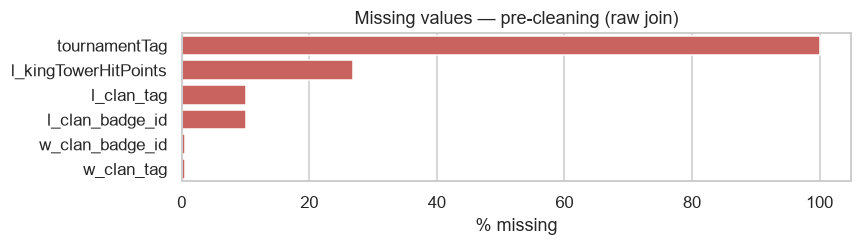

,missing_%
tournamentTag,100.00
l_kingTowerHitPoints,26.94
l_clan_tag,10.06
l_clan_badge_id,10.06
w_clan_badge_id,0.60
w_clan_tag,0.60


In [6]:
target_for_missing = raw if raw is not None else df
label = 'pre-cleaning (raw join)' if raw is not None else 'cleaned table'
miss = (target_for_missing.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
if len(miss) == 0:
    print(f'No missing values in the {label}.')
else:
    fig, ax = plt.subplots(figsize=(8, max(2, 0.4*len(miss))))
    sns.barplot(x=miss.values, y=miss.index, ax=ax, color='#d9534f')
    ax.set_xlabel('% missing'); ax.set_ylabel('')
    ax.set_title(f'Missing values — {label}')
    plt.tight_layout(); plt.show()
    display(miss.round(2).to_frame('missing_%'))

## 4. The modeling target: `is_A_winner`

In `preprocessed_match` the winner is implicit (the `w_` side). The model instead uses a **randomised** A/B relabelling so the winner is not always the same column; the resulting target `is_A_winner` is balanced ~50/50, which means the model must genuinely learn from the comparison features rather than from column position. A naive baseline is therefore 50% accuracy.

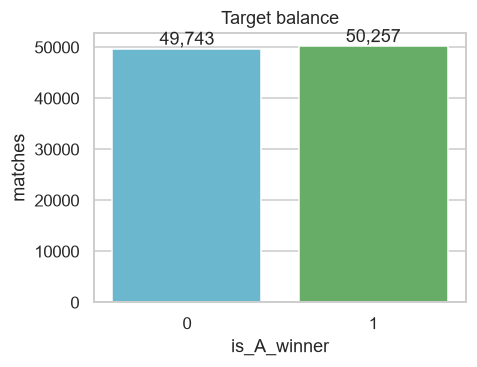

{0: 49.74, 1: 50.26}


In [7]:
if model_ready is not None and 'is_A_winner' in model_ready.columns:
    counts = model_ready['is_A_winner'].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    sns.barplot(x=counts.index.astype(str), y=counts.values, hue=counts.index.astype(str),
                legend=False, palette=['#5bc0de', '#5cb85c'], ax=ax)
    ax.set_xlabel('is_A_winner'); ax.set_ylabel('matches'); ax.set_title('Target balance')
    for i, v in enumerate(counts.values):
        ax.text(i, v, f'{v:,}', ha='center', va='bottom')
    plt.tight_layout(); plt.show()
    print((counts / counts.sum() * 100).round(2).to_dict())
else:
    print('model_ready_match not available; target is ~50/50 by construction.')

## 5. Pre-match feature distributions — winner vs loser

For each key **pre-match** feature, the winning and losing sides are overlaid. Where the two curves separate, that feature carries genuine pre-match signal about who wins.

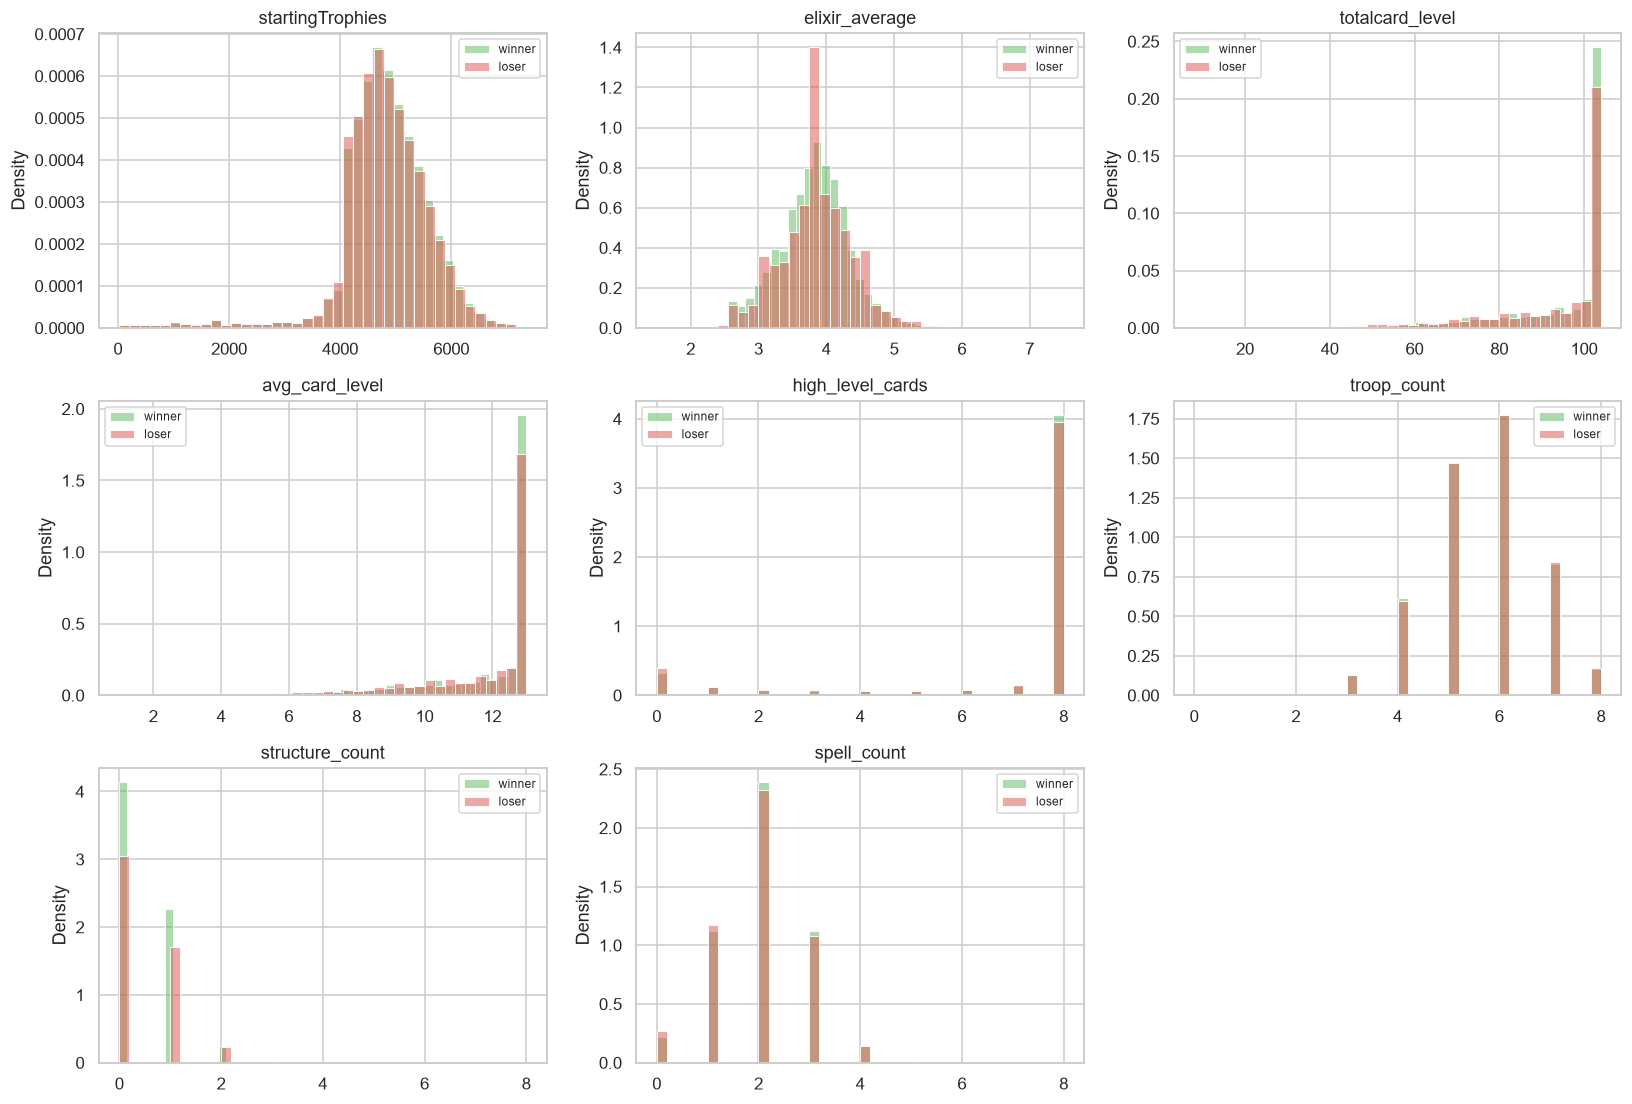

In [8]:
key_feats = [f for f in ['startingTrophies', 'elixir_average', 'totalcard_level',
                         'avg_card_level', 'high_level_cards', 'troop_count',
                         'structure_count', 'spell_count'] if f'w_{f}' in df.columns]
n = len(key_feats); ncols = 3; nrows = int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.4*nrows))
for ax, f in zip(axes.ravel(), key_feats):
    sns.histplot(df[f'w_{f}'], bins=40, stat='density', color='#5cb85c', alpha=0.5, label='winner', ax=ax)
    sns.histplot(df[f'l_{f}'], bins=40, stat='density', color='#d9534f', alpha=0.5, label='loser', ax=ax)
    ax.set_title(f); ax.set_xlabel(''); ax.legend(fontsize=8)
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

## 6. Winner-minus-loser gaps

Distribution of `winner - loser` for each pre-match feature. A distribution centred to the right of 0 means winners tend to have *more* of that feature. These gaps are exactly the kind of comparison the model's `diff_*` features encode.

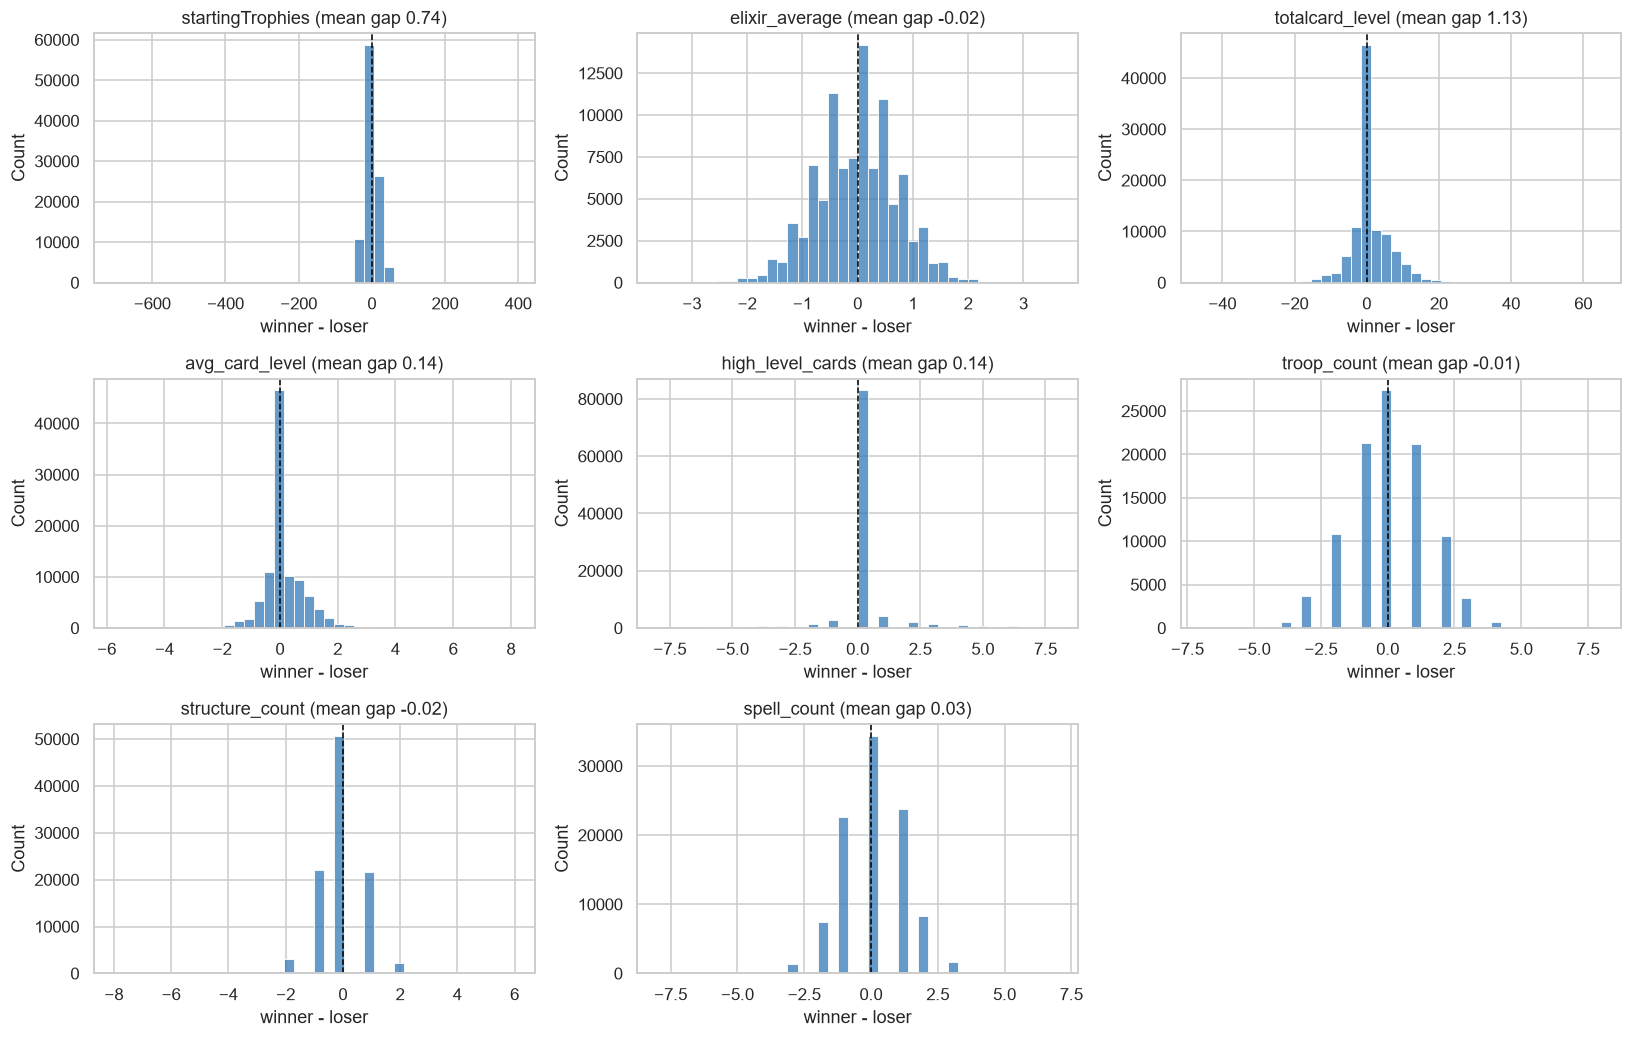

,mean_winner_minus_loser
startingTrophies,0.743
elixir_average,-0.020
totalcard_level,1.129
avg_card_level,0.141
high_level_cards,0.137
troop_count,-0.006
structure_count,-0.025
spell_count,0.031


In [9]:
gap_feats = key_feats
n = len(gap_feats); ncols = 3; nrows = int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2*nrows))
means = {}
for ax, f in zip(axes.ravel(), gap_feats):
    gap = df[f'w_{f}'] - df[f'l_{f}']
    means[f] = gap.mean()
    sns.histplot(gap, bins=40, color='#337ab7', ax=ax)
    ax.axvline(0, color='black', ls='--', lw=1)
    ax.set_title(f'{f} (mean gap {gap.mean():.2f})'); ax.set_xlabel('winner - loser')
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()
pd.Series(means, name='mean_winner_minus_loser').round(3).to_frame()

## 7. Does the player with the higher value win?

For each pre-match feature, among matches where the two players differ, the bar shows how often the player with the **higher** value is the winner. Above 50% means a higher value favours winning; near 50% means the feature alone barely decides the match.

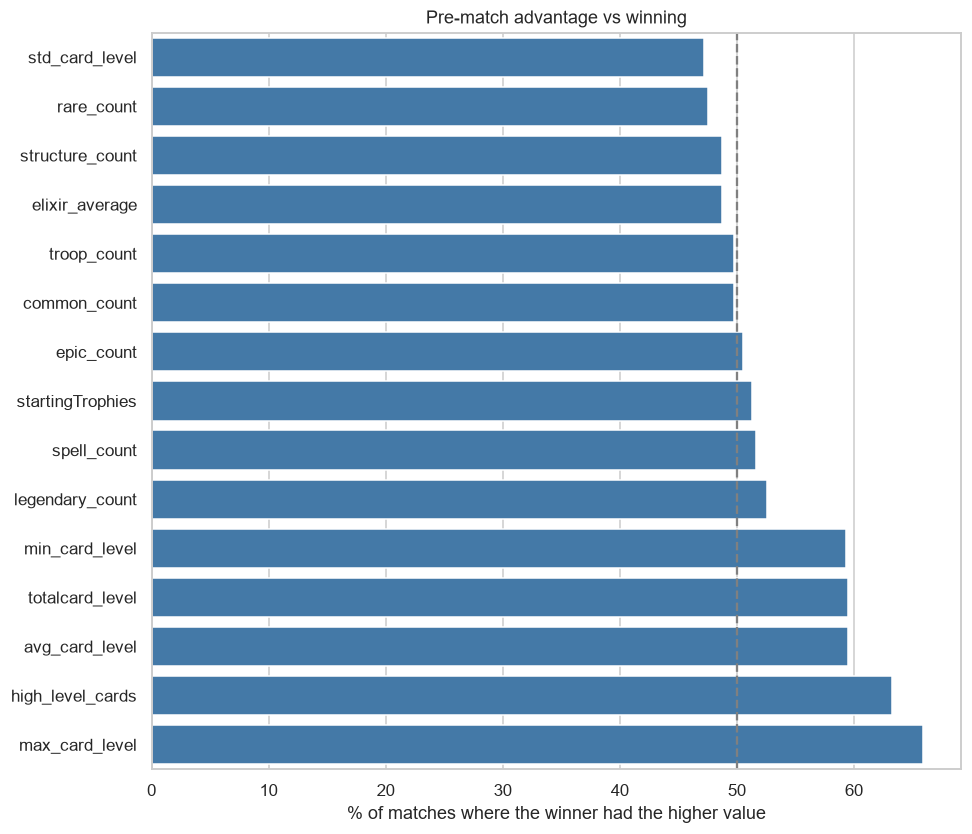

,feature,winner_has_higher_%,matches_differ_%
0,std_card_level,47.18,69.78
1,rare_count,47.55,77.34
2,structure_count,48.72,49.30
3,elixir_average,48.75,93.01
4,troop_count,49.73,72.63
5,common_count,49.75,78.42
6,epic_count,50.55,79.25
7,startingTrophies,51.31,94.10
8,spell_count,51.61,65.63
9,legendary_count,52.58,72.85


In [10]:
rows = []
for f in PRE_MATCH:
    wc, lc = f'w_{f}', f'l_{f}'
    if wc in df.columns and lc in df.columns:
        w, l = df[wc], df[lc]
        mask = w != l
        if mask.sum() > 0:
            rows.append((f, (w[mask] > l[mask]).mean() * 100, mask.mean() * 100))
adv = pd.DataFrame(rows, columns=['feature', 'winner_has_higher_%', 'matches_differ_%'])
adv = adv.sort_values('winner_has_higher_%')
fig, ax = plt.subplots(figsize=(9, 0.45*len(adv)+1))
sns.barplot(data=adv, x='winner_has_higher_%', y='feature', ax=ax, color='#337ab7')
ax.axvline(50, color='grey', ls='--')
ax.set_xlabel('% of matches where the winner had the higher value'); ax.set_ylabel('')
ax.set_title('Pre-match advantage vs winning')
plt.tight_layout(); plt.show()
adv.round(2).reset_index(drop=True)

## 8. Outliers

Box plots of the pre-match features (winner and loser pooled, z-scored only for a shared visual scale). Extreme deck-composition counts reflect valid gameplay variety rather than data errors.

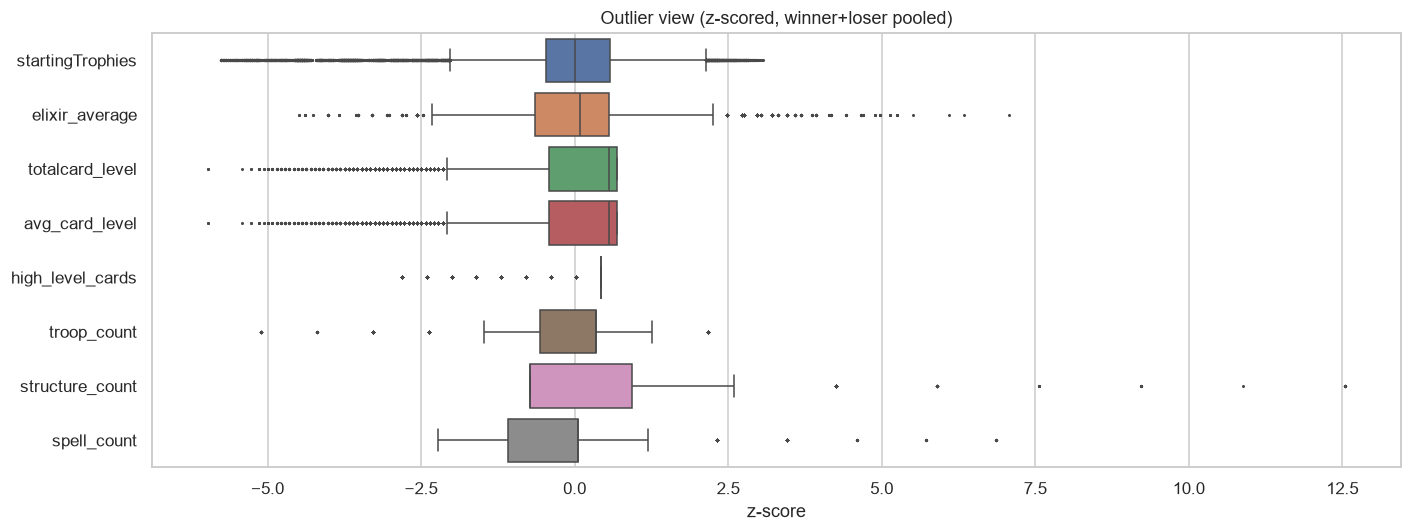

In [11]:
pool = pd.concat([
    df[[f'w_{f}' for f in key_feats]].rename(columns=lambda c: c[2:]),
    df[[f'l_{f}' for f in key_feats]].rename(columns=lambda c: c[2:]),
], ignore_index=True)
norm = (pool - pool.mean()) / pool.std(ddof=0)
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=norm, orient='h', ax=ax, fliersize=1)
ax.set_title('Outlier view (z-scored, winner+loser pooled)'); ax.set_xlabel('z-score')
plt.tight_layout(); plt.show()

## 9. Correlation among winner-minus-loser gaps

Correlation of the pre-match `winner - loser` gaps. Tight clusters (e.g. the card-rarity gaps) flag redundancy that the feature-engineering stage prunes before modeling.

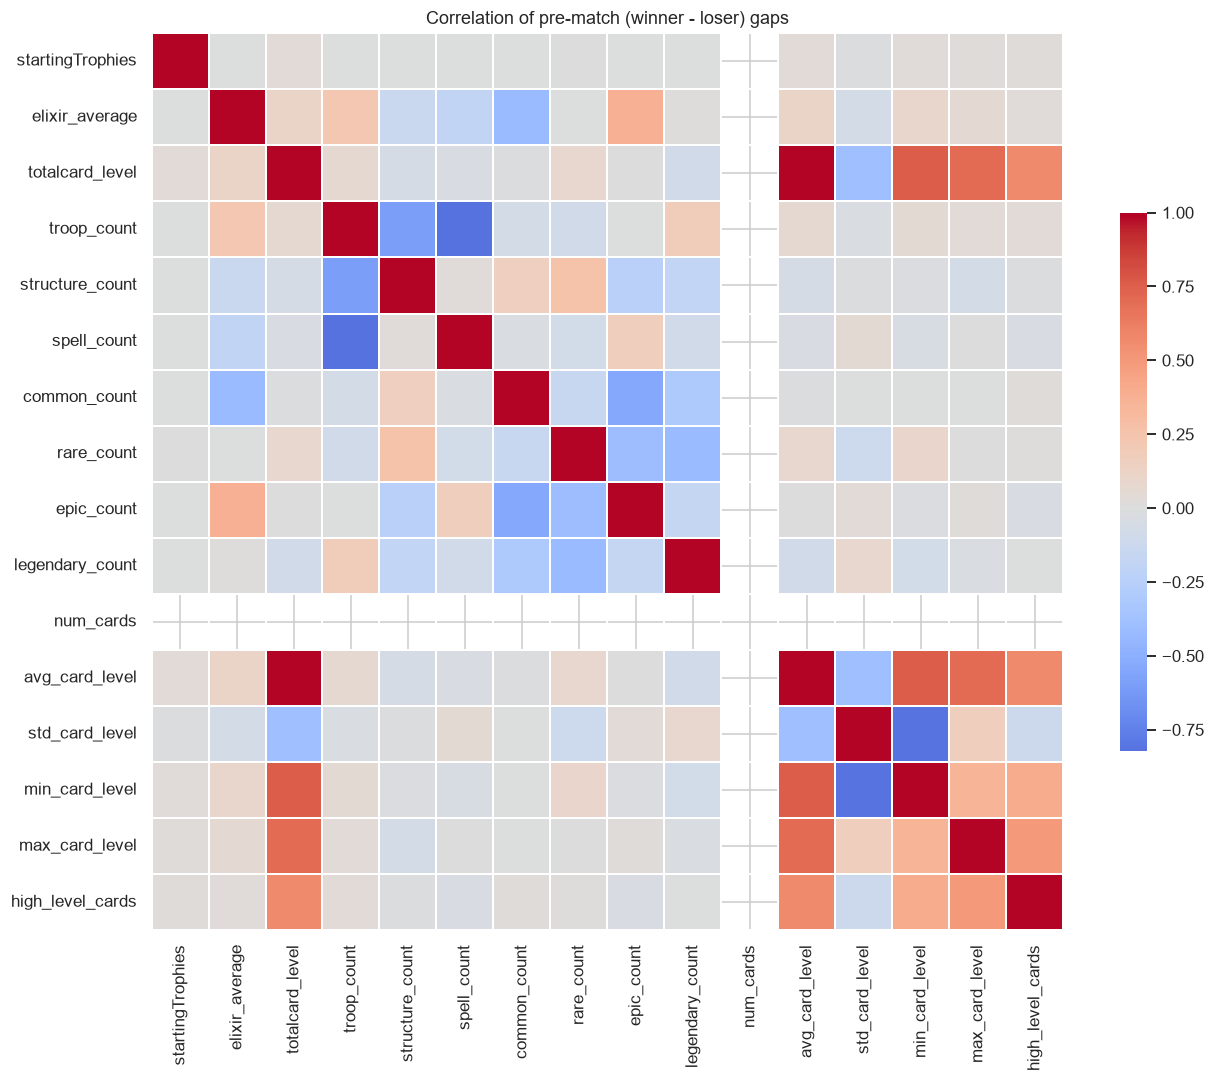

In [12]:
gaps = pd.DataFrame({f: df[f'w_{f}'] - df[f'l_{f}'] for f in PRE_MATCH if f'w_{f}' in df.columns})
corr = gaps.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3, cbar_kws={'shrink': 0.6}, ax=ax)
ax.set_title('Correlation of pre-match (winner - loser) gaps')
plt.tight_layout(); plt.show()

## 10. Temporal patterns

When are matches played? Uses the match-level `battle_hour` / `battle_dayofweek` (0 = Monday). We look at match **volume**.

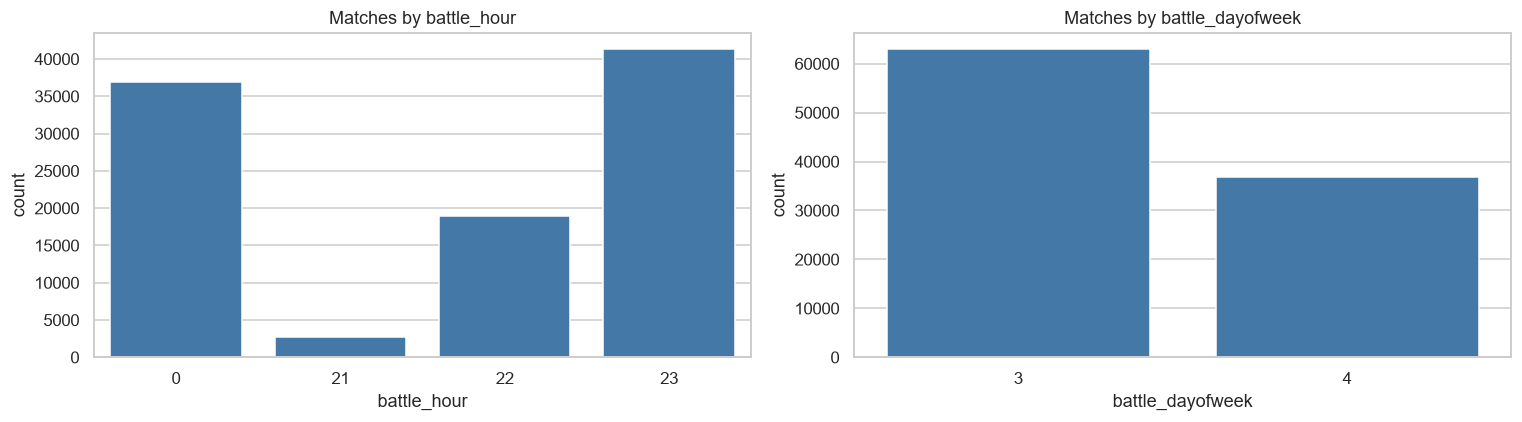

In [13]:
time_cols = [c for c in ['battle_hour', 'battle_dayofweek'] if c in df.columns]
if time_cols:
    fig, axes = plt.subplots(1, len(time_cols), figsize=(7*len(time_cols), 4))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, time_cols):
        order = sorted(df[col][df[col] >= 0].unique())
        sns.countplot(data=df[df[col] >= 0], x=col, order=order, ax=ax, color='#337ab7')
        ax.set_title(f'Matches by {col}')
    plt.tight_layout(); plt.show()
else:
    print('No temporal columns available.')

## 11. Card insights

Most-used cards and their win rate, read from the normalized `MatchPlayerCard` -> `Card` tables — the payoff of keeping cards in a child table rather than wide columns.

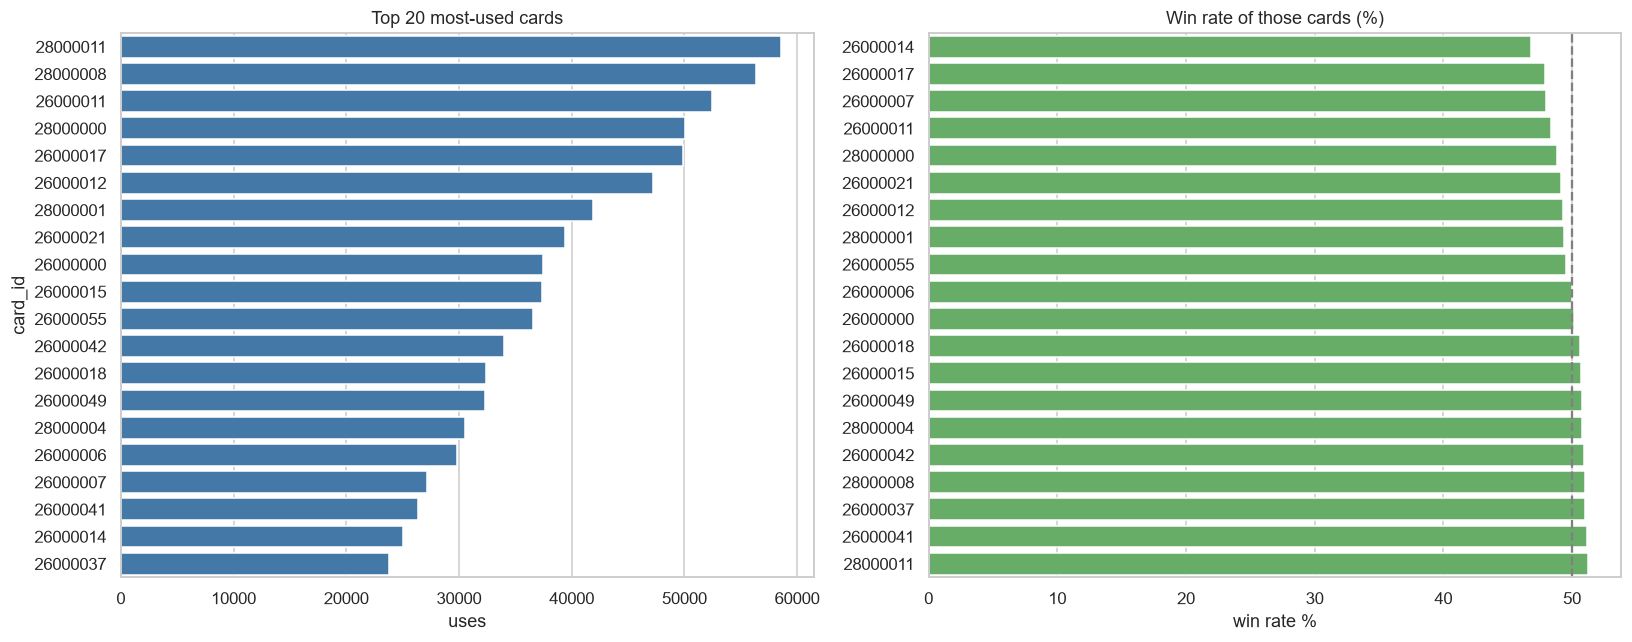

,card_id,uses,win_rate
0,28000011,58533,51.27
1,28000008,56350,50.98
2,26000011,52406,48.37
3,28000000,50061,48.84
4,26000017,49837,47.88
5,26000012,47251,49.27
6,28000001,41913,49.39
7,26000021,39438,49.14
8,26000000,37482,50.16
9,26000015,37324,50.69


In [14]:
if raw is not None:
    card_q = '''
        SELECT mpc."card_id" AS card_id,
               COUNT(*) AS uses,
               AVG(CASE WHEN mp."is_winner" THEN 1.0 ELSE 0.0 END) AS win_rate
        FROM "MatchPlayerCard" mpc
        JOIN "MatchPlayer" mp ON mp."id" = mpc."match_player_id"
        GROUP BY mpc."card_id"
        ORDER BY uses DESC
        LIMIT 20
    '''
    cards = pd.read_sql_query(card_q, engine)
    cards['win_rate'] = (cards['win_rate'] * 100).round(2)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.barplot(data=cards, y=cards['card_id'].astype(str), x='uses', ax=axes[0], color='#337ab7')
    axes[0].set_title('Top 20 most-used cards'); axes[0].set_ylabel('card_id'); axes[0].set_xlabel('uses')
    sns.barplot(data=cards.sort_values('win_rate'), y=cards.sort_values('win_rate')['card_id'].astype(str),
                x='win_rate', ax=axes[1], color='#5cb85c')
    axes[1].axvline(50, color='grey', ls='--')
    axes[1].set_title('Win rate of those cards (%)'); axes[1].set_ylabel(''); axes[1].set_xlabel('win rate %')
    plt.tight_layout(); plt.show()
    display(cards)
else:
    print('Card-level analysis needs the database (MatchPlayerCard / Card tables).')